# Machine Learning in Finance – Week 2
## Question 1: Testing Gradient Descent 
We apply the Gradient Descent algorithm to find the minimum of three functions:

$$f_1(x) := |x - b|^{1.5}, \quad f_2(x) := |x - b|^{0.5}, \quad f_3(x) := |x - b|^{3}$$

where $b \sim \mathcal{N}(1,1)$.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt


#### Parameters
dig = 4  ## number of digits after dot to be shown
## Number of gradient descent steps
N = 20
## Initial learning rate. Standard value in Tensorflow is eta = 0.001
eta1 = 1
## Update learning rate according to eta = eta1 / step ??
dynamic = True


#### Start of Program
#### Supposedly unknown parameters
## Generate an 'unknown' optimum b
b = np.random.normal(1,1)

## Standard normal starting position — drawn once, shared across all three functions
x0 = np.random.normal(0,1)

 $f_1(x) = |x - b|^{1.5}$

**Derivative:** $f_1'(x) = 1.5 \cdot |x-b|^{0.5} \cdot \operatorname{sign}(x-b)$

The derivative is well-defined everywhere except exactly at $x = b$, where `np.sign` returns 0


Start at: 1.7492 
with initial objective value is: 3.7289   with a Gradient: 2.326

Do 20 Gradient descent steps at initial learning rate: 1 ... with dynamic reduction of learning rate.


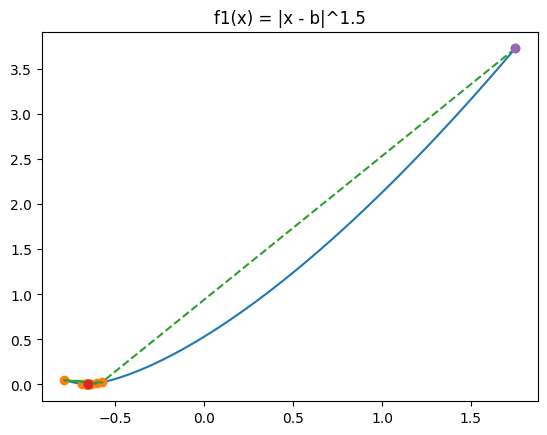



Ended at: -0.6569 where the optimal value is: -0.6555
Final objective value: 0.0001 with derivative: -0.0562 while the minimal value is: 0.0


In [3]:
## The function f is as 'unknown' as b is. Its minimal value is in x=b
def f(x):
    return( np.abs(x-b) ** 1.5 )

## Derivative of f
def fp(x):
    ## 1.5 * |x-b|^0.5 * sign(x-b)
    return( 1.5 * np.abs(x-b) ** 0.5 * np.sign(x-b) )

## If the derivative of f is not obtainable, use numerical derivative:
def fpn(x,eps=0.00001):
    y = (f(x+eps) - f(x-eps))/(2*eps)
    return(y)

## Use the next line if you like to try the numerical derivative instead
#fp = fpn

x = np.array(x0).reshape(1,)  # x0 as a vector of length 1

print("\nStart at:",round(x0,dig),"\nwith initial objective value is:",round(f(x0),dig),"  with a Gradient:",round(fp(x0),dig))


## Report on initial values
print("\nDo",N,"Gradient descent steps at initial learning rate:",eta1, end=" ")
if dynamic:
    print("... with dynamic reduction of learning rate.")

x_new = x0
for i in range(N):
    if dynamic:
        eta = eta1/(i+1)
    else:
        eta = eta1
    x_current = x_new
    x_new = x_current - eta * fp(x_current)  ## Gradient descent update is here
    x_new = np.array(x_new).reshape(1,)
    x = np.concatenate( (x,x_new) )


grid = np.linspace( min(np.min(x),b)  , max(np.max(x),b)  )
plt.plot(grid,f(grid))
plt.plot(x,f(x), 'o')
plt.plot(x,f(x), '--')
plt.plot(b,f(b), 'o')
plt.plot(x0,f(x0), 'o')
plt.title("f1(x) = |x - b|^1.5")
plt.show()


x_end = x[-1]
print("\n\nEnded at:",round(x_end,4),"where the optimal value is:",round(b,dig))
print("Final objective value:",round(f(x_end),dig),"with derivative:",round(fp(x_end),dig),"while the minimal value is:",round(f(b),dig))

## $f_2(x) = |x - b|^{0.5}$

Derivative: $f_2'(x) = 0.5 \cdot |x-b|^{-0.5} \cdot \operatorname{sign}(x-b)$

The derivative blows up as $x \to b$ because of the $|x-b|^{-0.5}$ term (division by a value approaching zero).


Start at: 1.7492 
with initial objective value is: 1.5507   with a Gradient: 0.3224

Do 20 Gradient descent steps at initial learning rate: 1 ... with dynamic reduction of learning rate.


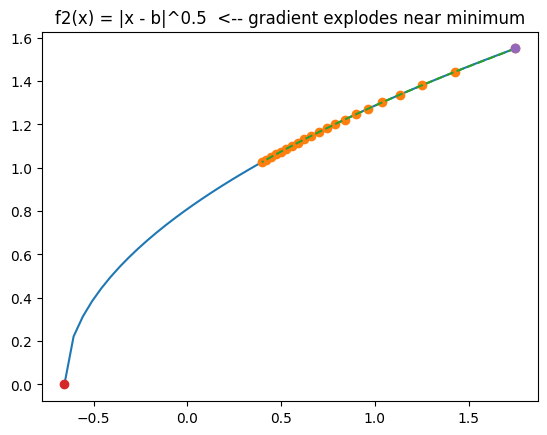



Ended at: 0.3971 where the optimal value is: -0.6555
Final objective value: 1.026 with derivative: 0.4873 while the minimal value is: 0.0


In [4]:
## The function f is as 'unknown' as b is. Its minimal value is in x=b
def f(x):
    return( np.abs(x-b) ** 0.5 )

## Derivative of f
def fp(x):
    ## 0.5 * |x-b|^(-0.5) * sign(x-b)
    ## IMPORTANT: explodes when x is very close to b  ->  GD diverges near the minimum
    return( 0.5 * np.abs(x-b) ** (-0.5) * np.sign(x-b) )

## If the derivative of f is not obtainable, use numerical derivative:
def fpn(x,eps=0.00001):
    y = (f(x+eps) - f(x-eps))/(2*eps)
    return(y)

## Use the next line if you like to try the numerical derivative instead
#fp = fpn

x = np.array(x0).reshape(1,)  # x0 as a vector of length 1

print("\nStart at:",round(x0,dig),"\nwith initial objective value is:",round(f(x0),dig),"  with a Gradient:",round(fp(x0),dig))


## Report on initial values
print("\nDo",N,"Gradient descent steps at initial learning rate:",eta1, end=" ")
if dynamic:
    print("... with dynamic reduction of learning rate.")

x_new = x0
for i in range(N):
    if dynamic:
        eta = eta1/(i+1)
    else:
        eta = eta1
    x_current = x_new
    x_new = x_current - eta * fp(x_current)  ## Gradient descent update is here
    x_new = np.array(x_new).reshape(1,)
    x = np.concatenate( (x,x_new) )


grid = np.linspace( min(np.min(x),b)  , max(np.max(x),b)  )
plt.plot(grid,f(grid))
plt.plot(x,f(x), 'o')
plt.plot(x,f(x), '--')
plt.plot(b,f(b), 'o')
plt.plot(x0,f(x0), 'o')
plt.title("f2(x) = |x - b|^0.5  <-- gradient explodes near minimum")
plt.show()


x_end = x[-1]
print("\n\nEnded at:",round(x_end,4),"where the optimal value is:",round(b,dig))
print("Final objective value:",round(f(x_end),dig),"with derivative:",round(fp(x_end),dig),"while the minimal value is:",round(f(b),dig))

## Cell 4 – $f_3(x) = |x - b|^{3}$

Derivative: $f_3'(x) = 3 \cdot |x-b|^{2} \cdot \operatorname{sign}(x-b)$
GD steps shrink rapidly and convergence is very slow. GD does eventually reach the minimum but needs far more steps than for a standard quadratic.


Start at: 1.7492 
with initial objective value is: 13.9046   with a Gradient: 17.3471

Do 20 Gradient descent steps at initial learning rate: 1 ... with dynamic reduction of learning rate.


/var/folders/c2/6pmxt6c54gd9mqjqkkxsqtbh0000gn/T/ipykernel_77923/3797134193.py:9: RuntimeWarning: overflow encountered in square
  return( 3 * np.abs(x-b) ** 2 * np.sign(x-b) )
/var/folders/c2/6pmxt6c54gd9mqjqkkxsqtbh0000gn/T/ipykernel_77923/3797134193.py:36: RuntimeWarning: invalid value encountered in subtract
  x_new = x_current - eta * fp(x_current)  ## Gradient descent update is here
/var/folders/c2/6pmxt6c54gd9mqjqkkxsqtbh0000gn/T/ipykernel_77923/3797134193.py:3: RuntimeWarning: overflow encountered in power
  return( np.abs(x-b) ** 3 )


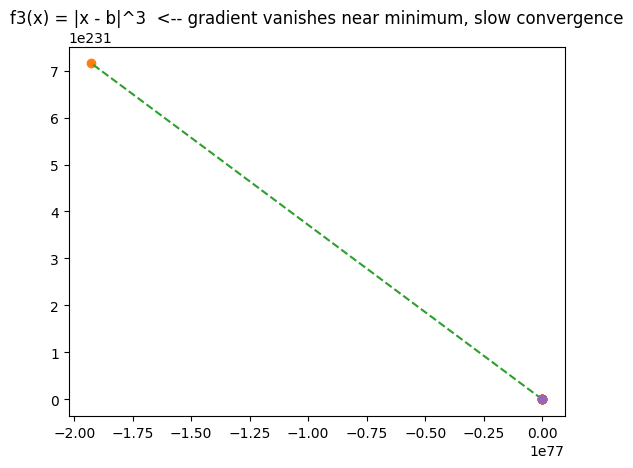



Ended at: nan where the optimal value is: -0.6555
Final objective value: nan with derivative: nan while the minimal value is: 0.0


In [5]:
## The function f is as 'unknown' as b is. Its minimal value is in x=b
def f(x):
    return( np.abs(x-b) ** 3 )

## Derivative of f
def fp(x):
    ## 3 * |x-b|^2 * sign(x-b)
    ## Gradient vanishes quadratically near x=b  ->  very slow convergence
    return( 3 * np.abs(x-b) ** 2 * np.sign(x-b) )

## If the derivative of f is not obtainable, use numerical derivative:
def fpn(x,eps=0.00001):
    y = (f(x+eps) - f(x-eps))/(2*eps)
    return(y)

## Use the next line if you like to try the numerical derivative instead
#fp = fpn

x = np.array(x0).reshape(1,)  # x0 as a vector of length 1

print("\nStart at:",round(x0,dig),"\nwith initial objective value is:",round(f(x0),dig),"  with a Gradient:",round(fp(x0),dig))


## Report on initial values
print("\nDo",N,"Gradient descent steps at initial learning rate:",eta1, end=" ")
if dynamic:
    print("... with dynamic reduction of learning rate.")

x_new = x0
for i in range(N):
    if dynamic:
        eta = eta1/(i+1)
    else:
        eta = eta1
    x_current = x_new
    x_new = x_current - eta * fp(x_current)  ## Gradient descent update is here
    x_new = np.array(x_new).reshape(1,)
    x = np.concatenate( (x,x_new) )


grid = np.linspace( min(np.min(x),b)  , max(np.max(x),b)  )
plt.plot(grid,f(grid))
plt.plot(x,f(x), 'o')
plt.plot(x,f(x), '--')
plt.plot(b,f(b), 'o')
plt.plot(x0,f(x0), 'o')
plt.title("f3(x) = |x - b|^3  <-- gradient vanishes near minimum, slow convergence")
plt.show()


x_end = x[-1]
print("\n\nEnded at:",round(x_end,4),"where the optimal value is:",round(b,dig))
print("Final objective value:",round(f(x_end),dig),"with derivative:",round(fp(x_end),dig),"while the minimal value is:",round(f(b),dig))

GD works well when the gradient is a proportional signal of how far we are from the minimum. Problems arise at the two extremes:
- **Exponent < 1** ($f_2$): The function is concave near the minimum, so the gradient is *too large* close to $b$. GD cannot take small enough steps to land on it...
- **Exponent > 2** ($f_3$): The function is very flat near the minimum, so the gradient is too small. GD makes negligible progress once it gets close...

## Question 2: Implementing Batch Sizes

We take GDforRegression.py and modify the GD loop to use mini-batches.
Instead of computing the gradient on the full dataset (K=200), we shuffle x and y together,
then cycle through batches of size batch_size=50. Each batch produces one gradient update,
so one 'epoch' (full pass through the data) gives K/batch_size = 4 mini-steps.

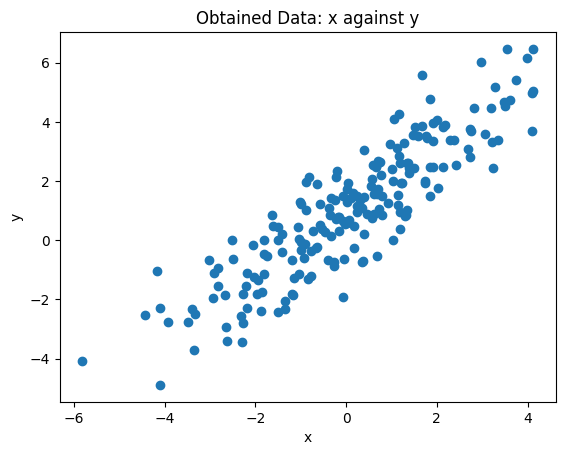

In [6]:
import numpy as np
import matplotlib.pyplot as plt


#### Parameters
## Number of observations
K = 200
## Number of test observations
Ktest = 100
## Input dimension
m = 1
## Output dimension
d = 1

## Number of digits shown
dig = 4

## GD parameters
## Number of gradient descent steps (here: number of full passes over the data, i.e. epochs)
N = 50
## Initial learning rate
eta1 = 1
## Update learning rate according to eta = eta1 / step ??
dynamic = True

## Batch size: number of data points used per gradient update
## K / batch_size = 200 / 50 = 4 mini-steps per epoch
batch_size = 50


#### K Random observations of input respectively output dimension
x = np.random.normal(0,2,(K,m))
y = x[:,0:d] + np.random.normal(1,1,(K,d))
if m == 1:
    if d == 1:
        plt.plot(x,y,'o')
        plt.title("Obtained Data: x against y")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()

## Model Setup (identical to GDforRegression.py)

In [7]:
#### Model setup
## Loss function
# L expects matrices y_pred, y where it computes
# a vector with the squared Euclidean distances of the rows
# Each row is treated separately
def L(y_pred,y):
    return np.sum( (y_pred-y)**2, axis=1) ## scalar product with itself


## Initial setup: Here for xA + b = y
A = np.random.normal(0,1,(m,d))
b = np.random.normal(0,1,(d,))


#### Network, simple affine network
def g(x,A,b):
    return np.dot(x,A) + b


## We like to minimise the total loss f:
def f(x,y,A,b):
    y_pred = g(x,A,b)
    return np.mean(L( y_pred , y ))

## Numerical gradient of f, eps is the precision in the derivative approximation
def df(x,y,A,b,eps=0.0001):
    dA = np.zeros(np.shape(A)) ## initialise
    db = np.zeros(np.shape(b)) ## initialise
    ## The following is a highly non-optimal way of computing the gradient:
    for i in range(d):
        e = np.zeros(d)
        e[i] = 1
        db[i] = (f(x,y,A,b+eps*e) - f(x,y,A,b-eps*e)) / (2*eps)
        for j in range(m):
            e = np.zeros((m,d))
            e[j,i] = 1
            dA[j,i] = (f(x,y,A+eps*e,b) - f(x,y,A-eps*e,b)) / (2*eps)
    return(dA,db)


print("\nStart at:\n",np.round(A,dig),"\nand intercept:",np.round(b,dig),"\nwith initial objective value is:",np.round(f(x,y,A,b),dig))


Start at:
 [[-0.7881]] 
and intercept: [-0.3501] 
with initial objective value is: 15.5887


Now instead of passing the full x,y into df(), we:
(a) shuffle x and y together at the start of each epoch,
(b) split into batches of size batch_size,
(c) do one gradient update per batch.

The learning rate counter step is shared across all mini-steps so it keeps
decreasing monotonically across the whole training run.


Ended at:
 [[0.9929]] 
and intercept: [0.9078] 
with final objective value (on-sample) is: 1.1846


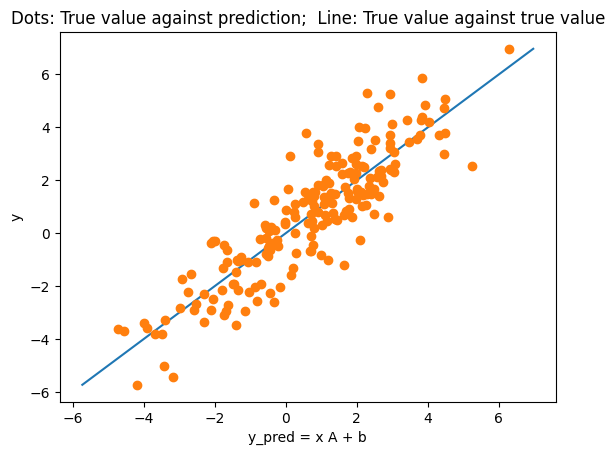

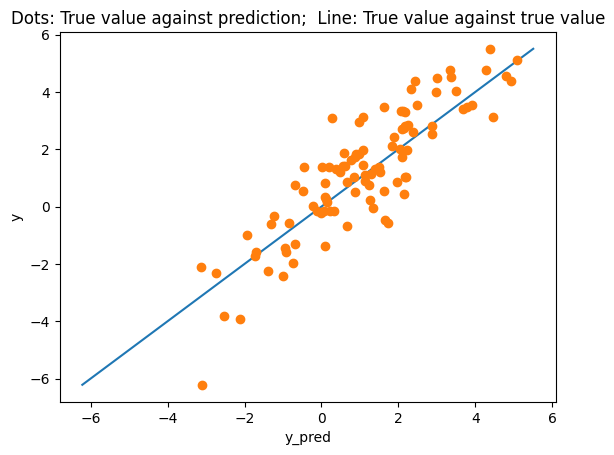


Objective value (out-of-sample) is: 1.1317


In [11]:
## Now, we do the actual gradient descent with mini-batches:

## step counts the total number of gradient updates across all epochs and batches
## used for the dynamic learning rate eta = eta1 / step  (same formula as GDforRegression.py)
step = 0

for i in range(N):  ## loop over epochs (full passes through the data)

    ## (a) Shuffle x and y together using the same permutation
    ## np.random.permutation gives a random ordering of indices 0..K-1
    ## applying the same index array to both x and y keeps (x_k, y_k) pairs intact
    perm = np.random.permutation(K)
    x_shuffle = x[perm]
    y_shuffle = y[perm]

    ## (b) and (c) Loop over batches of size batch_size
    ## K // batch_size = 4 batches per epoch for K=200, batch_size=50
    for j in range(K // batch_size):
        ## Extract the j-th batch
        x_batch = x_shuffle[ j*batch_size : (j+1)*batch_size ]
        y_batch = y_shuffle[ j*batch_size : (j+1)*batch_size ]

        step += 1  ## increment global step counter
        if dynamic:
            eta = eta1 / step
        else:
            eta = eta1

        ## Gradient is computed on the batch only, not the full data
        (dA,db) = df(x_batch, y_batch, A, b)
        #print("\n",A,"\n",eta*dA) ## for debugging purpose
        A = A - eta*dA  ## Gradient descent update for A
        b = b - eta*db  ## Gradient descent update for b


#### Model evaluation
print("\nEnded at:\n",np.round(A,dig),"\nand intercept:",np.round(b,dig),"\nwith final objective value (on-sample) is:",np.round(f(x,y,A,b),dig))


plt.plot([np.min(y),np.max(y)],[np.min(y),np.max(y)])
for i in range(d):
    plt.plot(g(x,A,b)[:,i],y[:,i],'o')
plt.title("Dots: True value against prediction;  Line: True value against true value")
plt.xlabel('y_pred = x A + b')
plt.ylabel('y')
plt.show()


## K Random observations of input respectively output dimension
xtest = np.random.normal(0,2,(Ktest,m))
ytest = xtest[:,0:d] + np.random.normal(1,1,(Ktest,d))

## Test plot:
plt.plot([np.min(ytest),np.max(ytest)],[np.min(ytest),np.max(ytest)])
for i in range(d):
    plt.plot(g(xtest,A,b)[:,i],ytest[:,i],'o')
plt.title("Dots: True value against prediction;  Line: True value against true value")
plt.xlabel('y_pred')
plt.ylabel('y')
plt.show()

print("\nObjective value (out-of-sample) is:",np.round(f(xtest,ytest,A,b),dig))